# Proof of Concept Pipeline (ERα SEGRIM)

Demonstrates the full dataset curation, multitask GCN modelling with deep ensemble uncertainty quantification, RDKit-based generative design, and computational validation pipeline described in the SEGRIM research proposal, using estrogen receptor alpha (ERα, ChEMBL ID: CHEMBL206) as a data-rich substitute for GR.

**Pipeline:**
1. Data curation (ChEMBL retrieval, structure standardisation, deduplication)
2. Multitask GCN with deep ensemble uncertainty quantification
3. Benchmarking: single-task GCN and RF baselines
4. RDKit atom-by-atom generative design with GCN reward scoring and Pareto selection
5. Computational validation with ADMET filters 

In [ ]:
import subprocess
packages = [
    'rdkit',
    'chembl-webresource-client',
    'torch',
    'torch-geometric',
    'scikit-learn',
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'meeko',
    'requests'
]
for pkg in packages:
    subprocess.run(['pip', 'install', pkg, '-q'], check=False)



## Data Curation

In [2]:
import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client

activity = new_client.activity

TARGET_MAP = {
    'ERa': 'CHEMBL206',
    'ERb': 'CHEMBL242',
    'PR':  'CHEMBL208',
    'AR':  'CHEMBL1871',
}

def fetch_bioactivity(chembl_id, label, standard_type='IC50', limit=500):
    res = activity.filter(
        target_chembl_id=chembl_id,
        standard_type=standard_type,
        standard_units='nM',
        standard_relation='='
    ).only([
        'molecule_chembl_id',
        'canonical_smiles',
        'standard_value',
        'standard_type',
        'assay_chembl_id',
        'document_chembl_id'
    ])
    df = pd.DataFrame(list(res)[:limit])
    df['target'] = label
    return df

dfs = [fetch_bioactivity(cid, label) for label, cid in TARGET_MAP.items()]
raw = pd.concat(dfs, ignore_index=True)
raw['standard_value'] = pd.to_numeric(raw['standard_value'], errors='coerce')
raw.dropna(subset=['canonical_smiles', 'standard_value'], inplace=True)

print(f"Raw records: {len(raw)}")
print(raw.groupby('target')['molecule_chembl_id'].count())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


Raw records: 1990
target
AR     498
ERa    492
ERb    500
PR     500
Name: molecule_chembl_id, dtype: int64


In [3]:
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.inchi import MolToInchiKey

def standardise_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None, None
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
        canonical = Chem.MolToSmiles(mol, canonical=True)
        inchi_key = MolToInchiKey(mol)
        return canonical, inchi_key
    except Exception:
        return None, None

raw[['std_smiles', 'inchi_key']] = raw['canonical_smiles'].apply(
    lambda s: pd.Series(standardise_smiles(s))
)
raw.dropna(subset=['std_smiles', 'inchi_key'], inplace=True)

curated = (
    raw.groupby(['inchi_key', 'target'])
    .agg(
        mean_ic50=('standard_value', 'mean'),
        n_records=('standard_value', 'count'),
        std_smiles=('std_smiles', 'first'),
        molecule_chembl_id=('molecule_chembl_id', 'first')
    )
    .reset_index()
)

stereo_check = raw.groupby('inchi_key')['std_smiles'].nunique()
curated['stereo_ambiguous'] = curated['inchi_key'].map(stereo_check) > 1

print(f"Curated records: {len(curated)}")
print(f"Stereochemically ambiguous: {curated['stereo_ambiguous'].sum()}")
print(curated.groupby('target')['inchi_key'].count())

[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21:14] Running LargestFragmentChooser
[21:21:14] Running Uncharger
[21:21

Curated records: 1411
Stereochemically ambiguous: 0
target
AR     368
ERa    326
ERb    341
PR     376
Name: inchi_key, dtype: int64


[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21:15] Running LargestFragmentChooser
[21:21:15] Running Uncharger
[21:21

In [4]:
ACTIVITY_CUTOFF_NM = 100

curated['active'] = (curated['mean_ic50'] <= ACTIVITY_CUTOFF_NM).astype(int)
curated = curated[curated['mean_ic50'] > 0]
curated['pic50'] = -np.log10(curated['mean_ic50'] * 1e-9)

pivot = (
    curated
    .pivot_table(
        index=['inchi_key', 'std_smiles', 'molecule_chembl_id'],
        columns='target',
        values='active'
    )
    .reset_index()
)
pivot.columns.name = None
pivot.dropna(subset=['ERa'], inplace=True)
pivot.fillna(-1, inplace=True)

print(f"Compounds with ERa data: {len(pivot)}")
print(pivot[['ERa', 'ERb', 'PR', 'AR']].describe())

Compounds with ERa data: 326
              ERa         ERb          PR          AR
count  326.000000  326.000000  326.000000  326.000000
mean     0.739264    0.469325   -0.996933   -0.993865
std      0.439711    0.595349    0.055385    0.110770
min      0.000000   -1.000000   -1.000000   -1.000000
25%      0.000000    0.000000   -1.000000   -1.000000
50%      1.000000    1.000000   -1.000000   -1.000000
75%      1.000000    1.000000   -1.000000   -1.000000
max      1.000000    1.000000    0.000000    1.000000


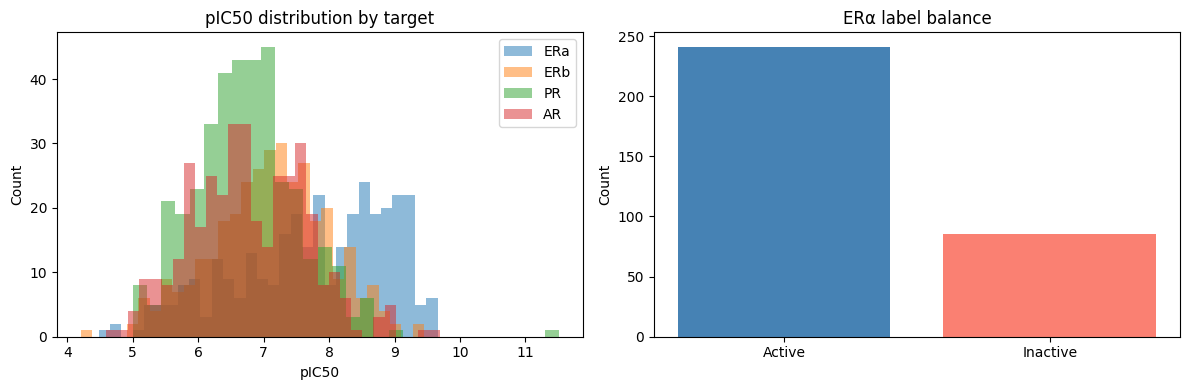

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label in TARGET_MAP.keys():
    subset = curated[curated['target'] == label]
    axes[0].hist(subset['pic50'], bins=30, alpha=0.5, label=label)
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title('pIC50 distribution by target')
axes[0].legend()

era_counts = pivot['ERa'].value_counts().rename({1.0: 'Active', 0.0: 'Inactive', -1.0: 'Missing'})
axes[1].bar(era_counts.index.astype(str), era_counts.values, color=['steelblue', 'salmon', 'grey'])
axes[1].set_title('ERα label balance')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('dataset_summary.png', dpi=150)
plt.show()


## Multitask GCN with Deep Ensemble Uncertainty Quantification

In [6]:
import torch
from torch_geometric.data import Data
from rdkit.Chem import rdchem

HYBRIDISATION_MAP = {
    rdchem.HybridizationType.SP:    0,
    rdchem.HybridizationType.SP2:   1,
    rdchem.HybridizationType.SP3:   2,
    rdchem.HybridizationType.SP3D:  3,
    rdchem.HybridizationType.SP3D2: 4,
    rdchem.HybridizationType.OTHER: 5,
}

BOND_TYPE_MAP = {
    rdchem.BondType.SINGLE:   0,
    rdchem.BondType.DOUBLE:   1,
    rdchem.BondType.TRIPLE:   2,
    rdchem.BondType.AROMATIC: 3,
}

def mol_to_graph(smiles, labels):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    atom_features = [
        [
            atom.GetAtomicNum(),
            HYBRIDISATION_MAP.get(atom.GetHybridization(), 5),
            atom.GetFormalCharge(),
            int(atom.GetIsAromatic()),
            atom.GetTotalNumHs(),
        ]
        for atom in mol.GetAtoms()
    ]
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j   = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        btype  = BOND_TYPE_MAP.get(bond.GetBondType(), 3)
        ring   = int(bond.IsInRing())
        edge_index += [[i, j], [j, i]]
        edge_attr  += [[btype, ring], [btype, ring]]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)
    y          = torch.tensor([labels],   dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

TASK_COLS = ['ERa', 'ERb', 'PR', 'AR']

graphs = []
smiles_list = []
for _, row in pivot.iterrows():
    labels = [row[t] for t in TASK_COLS]
    g = mol_to_graph(row['std_smiles'], labels)
    if g is not None:
        graphs.append(g)
        smiles_list.append(row['std_smiles'])

print(f"Valid molecular graphs: {len(graphs)}")
print(f"Node feature dim: {graphs[0].x.shape[1]}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Valid molecular graphs: 326
Node feature dim: 5


In [7]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

era_labels   = [int(g.y[0, 0].item()) for g in graphs]
labelled_idx = [i for i, l in enumerate(era_labels) if l != -1]
missing_idx  = [i for i, l in enumerate(era_labels) if l == -1]
lab_labels   = [era_labels[i] for i in labelled_idx]

train_idx, temp_idx = train_test_split(
    labelled_idx, test_size=0.2, stratify=lab_labels, random_state=42
)
temp_labels = [era_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_labels, random_state=42
)

train_data = [graphs[i] for i in train_idx] + [graphs[i] for i in missing_idx]
val_data   = [graphs[i] for i in val_idx]
test_data  = [graphs[i] for i in test_idx]

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=64)
test_loader  = DataLoader(test_data,  batch_size=64)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Train: 260 | Val: 33 | Test: 33


In [9]:
era_test_labels = [graphs[i].y[0, 0].item() for i in test_idx]
n_active_test   = sum(1 for l in era_test_labels if l == 1.0)
n_inactive_test = sum(1 for l in era_test_labels if l == 0.0)
print(f"Test set: {len(era_test_labels)} compounds")
print(f"Active: {n_active_test} | Inactive: {n_inactive_test}")

Test set: 33 compounds
Active: 24 | Inactive: 9


In [10]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class MultitaskGCN(nn.Module):
    def __init__(self, node_dim, hidden_dim, num_tasks, dropout=0.3, seed=None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.conv1 = GCNConv(node_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.bn3   = nn.BatchNorm1d(hidden_dim)
        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(hidden_dim, hidden_dim)
        self.heads = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(num_tasks)])

    def forward(self, x, edge_index, batch):
        h = F.relu(self.bn1(self.conv1(x, edge_index)))
        h = self.drop(h)
        h = F.relu(self.bn2(self.conv2(h, edge_index)))
        h = self.drop(h)
        h = F.relu(self.bn3(self.conv3(h, edge_index)))
        h = global_mean_pool(h, batch)
        h = F.relu(self.fc1(h))
        h = self.drop(h)
        return torch.cat([head(h) for head in self.heads], dim=1)

def masked_bce_loss(preds, targets, missing_val=-1, pos_weight=None):
    mask = targets != missing_val
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True)
    pw = pos_weight.to(preds.device) if pos_weight is not None else None
    return F.binary_cross_entropy_with_logits(
        preds[mask], targets[mask], reduction='mean', pos_weight=pw
    )

NODE_DIM   = graphs[0].x.shape[1]
HIDDEN_DIM = 128
NUM_TASKS  = len(TASK_COLS)
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")

Device: cpu


In [12]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

N_ENSEMBLE = 5
EPOCHS     = 50

era_train_labels = [g.y[0, 0].item() for g in train_data if g.y[0, 0].item() != -1]
n_active   = sum(1 for l in era_train_labels if l == 1)
n_inactive = sum(1 for l in era_train_labels if l == 0)
pos_weight = torch.tensor([n_inactive / n_active]) if n_active > 0 else torch.tensor([1.0])
print(f"ERa class weight: {pos_weight.item():.3f} (inactive/active ratio)")

def train_single_model(seed):
    model     = MultitaskGCN(NODE_DIM, HIDDEN_DIM, NUM_TASKS, seed=seed).to(device)
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_val  = np.inf
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = masked_bce_loss(model(batch.x, batch.edge_index, batch.batch), batch.y, pos_weight=pos_weight)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                val_loss += masked_bce_loss(
                    model(batch.x, batch.edge_index, batch.batch), batch.y
                ).item()
        avg_val = val_loss / max(len(val_loader), 1)
        scheduler.step(avg_val)

        if avg_val < best_val:
            best_val   = avg_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model

ensemble = []
for i in range(N_ENSEMBLE):
    print(f"  Model {i+1}/{N_ENSEMBLE}", end=' ')
    m = train_single_model(seed=42 + i * 7)
    ensemble.append(m)
    print("done")
print("Ensemble training complete.")

ERa class weight: 0.354 (inactive/active ratio)
  Model 1/5 done
  Model 2/5 done
  Model 3/5 done
  Model 4/5 done
  Model 5/5 done
Ensemble training complete.


In [13]:
def ensemble_predict(loader, ensemble, device):
    """
    Returns:
        mean_preds: (n_samples, n_tasks)
        std_preds:  (n_samples, n_tasks) - epistemic uncertainty
        targets:    (n_samples, n_tasks)
    """
    all_member_preds = []
    targets_list     = []

    for model in ensemble:
        model.eval()
        member_preds = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                p = torch.sigmoid(model(batch.x, batch.edge_index, batch.batch))
                member_preds.append(p.cpu())
                if len(all_member_preds) == 0:
                    targets_list.append(batch.y.cpu())
        all_member_preds.append(torch.cat(member_preds).numpy())

    stack       = np.stack(all_member_preds, axis=0)  # (n_members, n_samples, n_tasks)
    mean_preds  = stack.mean(axis=0)
    std_preds   = stack.std(axis=0)
    targets     = torch.cat(targets_list).numpy()
    return mean_preds, std_preds, targets

mean_preds, std_preds, targets = ensemble_predict(test_loader, ensemble, device)

print("Ensemble predictions on test set.")
print(f"Mean prediction shape: {mean_preds.shape}")
print(f"Uncertainty (std) shape: {std_preds.shape}")
print(f"\nMean epistemic uncertainty per task:")
for i, task in enumerate(TASK_COLS):
    mask = targets[:, i] != -1
    print(f"  {task}: {std_preds[mask, i].mean():.4f} +/- {std_preds[mask, i].std():.4f}")

Ensemble predictions on test set.
Mean prediction shape: (33, 4)
Uncertainty (std) shape: (33, 4)

Mean epistemic uncertainty per task:
  ERa: 0.0418 +/- 0.0285
  ERb: 0.0503 +/- 0.0299
  PR: nan +/- nan
  AR: nan +/- nan


/var/folders/0t/0c19_qsd04xb71k093l44mqc0000gn/T/ipykernel_51504/3944892998.py:37: RuntimeWarning: Mean of empty slice.
  print(f"  {task}: {std_preds[mask, i].mean():.4f} +/- {std_preds[mask, i].std():.4f}")
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in divid

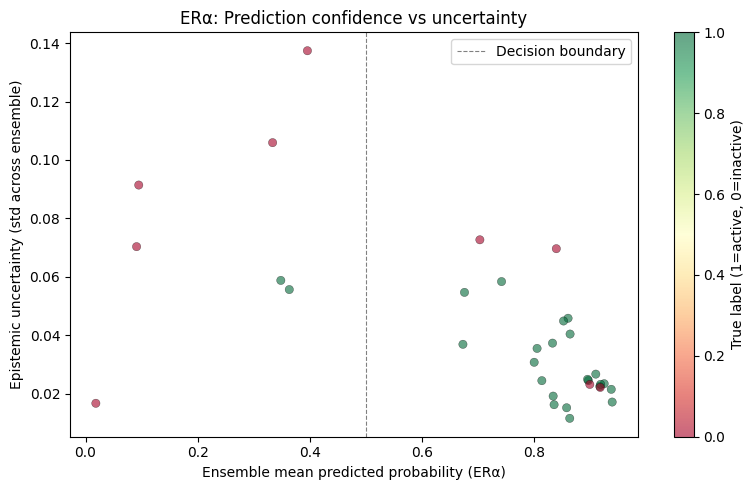

In [14]:
era_mask = targets[:, 0] != -1
era_mean = mean_preds[era_mask, 0]
era_std  = std_preds[era_mask, 0]
era_true = targets[era_mask, 0]

plt.figure(figsize=(8, 5))
sc = plt.scatter(era_mean, era_std, c=era_true, cmap='RdYlGn', alpha=0.6, edgecolors='k', linewidths=0.3)
plt.colorbar(sc, label='True label (1=active, 0=inactive)')
plt.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Decision boundary')
plt.xlabel('Ensemble mean predicted probability (ERα)')
plt.ylabel('Epistemic uncertainty (std across ensemble)')
plt.title('ERα: Prediction confidence vs uncertainty')
plt.legend()
plt.tight_layout()
plt.show()


## Benchmarking

In [15]:
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from rdkit.Chem import AllChem

mt_aucs = {}
for i, task in enumerate(TASK_COLS):
    mask = targets[:, i] != -1
    if mask.sum() < 10:
        print(f"  {task}: insufficient test labels")
        continue
    auc = roc_auc_score(targets[mask, i], mean_preds[mask, i])
    mt_aucs[task] = auc
    print(f"  {task}: {auc:.3f} (uncertainty: {std_preds[mask, i].mean():.3f})")


class SingleTaskGCN(nn.Module):
    def __init__(self, node_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(node_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.drop  = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        h = F.relu(self.bn1(self.conv1(x, edge_index)))
        h = self.drop(h)
        h = F.relu(self.bn2(self.conv2(h, edge_index)))
        h = global_mean_pool(h, batch)
        return self.fc(self.drop(h))


st_aucs = {}
for task_idx, task in enumerate(TASK_COLS):
    task_train = [g for g in train_data if g.y[0, task_idx].item() != -1]
    task_test  = [g for g in test_data  if g.y[0, task_idx].item() != -1]
    if len(task_train) < 20 or len(task_test) < 10:
        print(f"  {task}: insufficient data")
        continue

    st_loader_train = DataLoader(task_train, batch_size=32, shuffle=True)
    st_loader_test  = DataLoader(task_test,  batch_size=64)

    st_model   = SingleTaskGCN(NODE_DIM, HIDDEN_DIM).to(device)
    st_opt     = Adam(st_model.parameters(), lr=1e-3)

    for epoch in range(30):
        st_model.train()
        for batch in st_loader_train:
            batch = batch.to(device)
            y     = batch.y[:, task_idx].unsqueeze(1)
            st_opt.zero_grad()
            F.binary_cross_entropy_with_logits(
                st_model(batch.x, batch.edge_index, batch.batch), y
            ).backward()
            st_opt.step()

    st_model.eval()
    st_preds, st_targets = [], []
    with torch.no_grad():
        for batch in st_loader_test:
            batch = batch.to(device)
            p = torch.sigmoid(st_model(batch.x, batch.edge_index, batch.batch))
            st_preds.append(p.cpu())
            st_targets.append(batch.y[:, task_idx].cpu())
    st_preds   = torch.cat(st_preds).numpy().flatten()
    st_targets = torch.cat(st_targets).numpy()
    auc = roc_auc_score(st_targets, st_preds)
    st_aucs[task] = auc
    print(f"  {task}: {auc:.3f}")


def get_fp(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return list(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024))

train_rows = pivot.iloc[train_idx].reset_index(drop=True)
test_rows  = pivot.iloc[test_idx].reset_index(drop=True)
train_fps  = [get_fp(s) for s in train_rows['std_smiles']]
test_fps   = [get_fp(s) for s in test_rows['std_smiles']]


rf_aucs = {}
for task in TASK_COLS:
    y_train = train_rows[task].values
    y_test  = test_rows[task].values
    mt      = y_train != -1
    mte     = y_test  != -1
    if mt.sum() < 10 or mte.sum() < 10:
        continue
    X_tr = [train_fps[i] for i in range(len(train_fps)) if train_fps[i] and mt[i]]
    y_tr = y_train[mt[:len(train_fps)]]
    X_te = [test_fps[i]  for i in range(len(test_fps))  if test_fps[i]  and mte[i]]
    y_te = y_test[mte[:len(test_fps)]]
    rf   = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, rf.predict_proba(X_te)[:, 1])
    rf_aucs[task] = auc
    print(f"  {task}: {auc:.3f}")

  ERa: 0.745 (uncertainty: 0.042)
  ERb: 0.688 (uncertainty: 0.050)
  PR: insufficient test labels
  AR: insufficient test labels
  ERa: 0.718
  ERb: 0.738
  PR: insufficient data
  AR: insufficient data


[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerator
[21:23:19] DEPRECATION WARNING: please use MorganGenerat

  ERa: 0.917
  ERb: 0.748


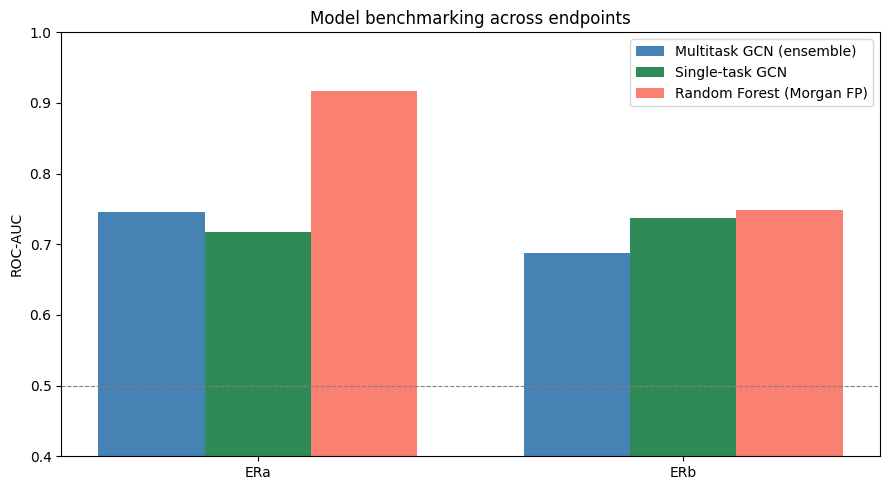

ROC-AUC Scores for ERα:
  Multitask GCN (ensemble): 0.745
  Single-task GCN: 0.718
  Random Forest (Morgan FP): 0.917


In [26]:
tasks_present = [t for t in TASK_COLS if t in mt_aucs]
x = np.arange(len(tasks_present))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, [mt_aucs.get(t, 0) for t in tasks_present], width, label='Multitask GCN (ensemble)', color='steelblue')
ax.bar(x,         [st_aucs.get(t, 0) for t in tasks_present], width, label='Single-task GCN',           color='seagreen')
ax.bar(x + width, [rf_aucs.get(t, 0) for t in tasks_present], width, label='Random Forest (Morgan FP)', color='salmon')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tasks_present)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.4, 1.0)
ax.set_title('Model benchmarking across endpoints')
ax.legend()
plt.tight_layout()
plt.savefig('benchmarking.png', dpi=150)
plt.show()

# print roc-auc scores for ERa
print("ROC-AUC Scores for ERα:")
print(f"  Multitask GCN (ensemble): {mt_aucs.get('ERa', 0):.3f}")
print(f"  Single-task GCN: {st_aucs.get('ERa', 0):.3f}")
print(f"  Random Forest (Morgan FP): {rf_aucs.get('ERa', 0):.3f}")


## RDKit Atom-by-Atom Generative Design

Generates novel molecules by iteratively adding atoms and bonds to a seed scaffold using RDKit's editable mol interface. At each step, only chemically valid additions are permitted. The trained ensemble scores each completed molecule, and candidates are selected via Pareto front optimisation. This mirrors the GraphINVENT atom-by-atom generation logic described in Aim 3.

In [17]:
from rdkit.Chem import RWMol, AllChem
from rdkit.Chem import rdMolDescriptors
import random

ATOM_TYPES   = [6, 7, 8, 9, 17]   # C, N, O, F, Cl
BOND_TYPES   = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
]
MAX_ATOMS    = 35
N_CANDIDATES = 50

def is_valid(mol):
    """Check chemical validity via sanitisation."""
    try:
        Chem.SanitizeMol(mol)
        return True
    except Exception:
        return False

def get_open_valences(mol):
    """Return list of (atom_idx, available_valence) for atoms with free valence."""
    open_sites = []
    for atom in mol.GetAtoms():
        max_val  = atom.GetTotalValence()
        used_val = sum([
            int(b.GetBondTypeAsDouble())
            for b in atom.GetBonds()
        ])
        free = max_val - used_val
        if free > 0:
            open_sites.append((atom.GetIdx(), free))
    return open_sites

def grow_molecule(seed_smiles, n_steps=5, rng_seed=None):
    """
    Grow a molecule from seed_smiles by adding n_steps atoms.
    Returns canonical SMILES of the grown molecule, or None if growth fails.
    """
    rng = random.Random(rng_seed)
    mol = Chem.RWMol(Chem.MolFromSmiles(seed_smiles))
    if mol is None:
        return None

    for _ in range(n_steps):
        if mol.GetNumAtoms() >= MAX_ATOMS:
            break
        open_sites = get_open_valences(mol)
        if not open_sites:
            break

        attach_idx, _ = rng.choice(open_sites)
        new_atomic    = rng.choice(ATOM_TYPES)
        bond_type     = rng.choice(BOND_TYPES)

        candidate = Chem.RWMol(mol)
        new_idx   = candidate.AddAtom(Chem.Atom(new_atomic))
        candidate.AddBond(attach_idx, new_idx, bond_type)

        if is_valid(candidate):
            mol = candidate

    try:
        Chem.SanitizeMol(mol)
        smi = Chem.MolToSmiles(mol, canonical=True)
        return smi
    except Exception:
        return None

SEED_SCAFFOLDS = [
    'OC1=CC2=C(CC[C@@H]3[C@@H]2CC[C@@]4(O)C3CC[C@H]4O)C=C1',  # Estradiol
    'OC1=CC=C(CCc2ccc(O)cc2)C=C1',                               # Bisphenol scaffold
]


generated_smiles = []
for i in range(N_CANDIDATES):
    seed  = random.choice(SEED_SCAFFOLDS)
    steps = random.randint(2, 6)
    smi   = grow_molecule(seed, n_steps=steps, rng_seed=i)
    if smi:
        std_smi, _ = standardise_smiles(smi)
        if std_smi:
            generated_smiles.append(std_smi)

generated_smiles = list(set(generated_smiles))
print(f"valid candidates: {len(generated_smiles)}")

valid candidates: 43


[21:23:52] Explicit valence for atom # 17 Cl, 2, is greater than permitted
[21:23:52] Running LargestFragmentChooser
[21:23:52] Running Uncharger
[21:23:52] Can't kekulize mol.  Unkekulized atoms: 1 2 3 18 19
[21:23:52] Explicit valence for atom # 8 C, 6, is greater than permitted
[21:23:52] Explicit valence for atom # 20 F, 2, is greater than permitted
[21:23:52] Explicit valence for atom # 0 O, 3, is greater than permitted
[21:23:52] Running LargestFragmentChooser
[21:23:52] Running Uncharger
[21:23:52] Can't kekulize mol.  Unkekulized atoms: 2 3 4 18 19
[21:23:52] Explicit valence for atom # 12 O, 3, is greater than permitted
[21:23:52] Explicit valence for atom # 8 C, 5, is greater than permitted
[21:23:52] Running LargestFragmentChooser
[21:23:52] Running Uncharger
[21:23:52] Explicit valence for atom # 7 C, 5, is greater than permitted
[21:23:52] Explicit valence for atom # 12 O, 3, is greater than permitted
[21:23:52] Running LargestFragmentChooser
[21:23:52] Running Uncharger
[

In [18]:
def score_with_ensemble(smiles, ensemble, device):
    g = mol_to_graph(smiles, [-1] * NUM_TASKS)
    if g is None:
        return None, None
    batch_vec = torch.zeros(g.x.shape[0], dtype=torch.long).to(device)
    member_preds = []
    for model in ensemble:
        model.eval()
        with torch.no_grad():
            g_dev = g.to(device)
            p = torch.sigmoid(model(g_dev.x, g_dev.edge_index, batch_vec))
            member_preds.append(p.cpu().numpy()[0])
    stack = np.stack(member_preds)          # (n_members, n_tasks)
    return stack.mean(axis=0), stack.std(axis=0)

scored = []
for smi in generated_smiles:
    mean, std = score_with_ensemble(smi, ensemble, device)
    if mean is None:
        continue
    scored.append({
        'smiles':       smi,
        'ERa_mean':     mean[0],
        'ERa_std':      std[0],
        'ERb_mean':     mean[1],
        'PR_mean':      mean[2],
        'AR_mean':      mean[3],
        'high_unc':     std[0] > 0.15,   # flag high uncertainty
    })

scored_df = pd.DataFrame(scored)
print(f"Scored candidates: {len(scored_df)}")
print(f"High uncertainty (ERa std > 0.15): {scored_df['high_unc'].sum()}")
print(scored_df.sort_values('ERa_mean', ascending=False).head(10))

Scored candidates: 43
High uncertainty (ERa std > 0.15): 2
                                               smiles  ERa_mean   ERa_std  \
5                  Cc1cc(CC(F)c2ccc(O)cc2Cl)c(Cl)cc1O  0.903050  0.045944   
35                 CC(c1ccc(O)cc1)C(N)c1ccc(O)c(Cl)c1  0.893576  0.028786   
40                        Oc1ccc(CCc2ccc(OF)cc2)cc1Cl  0.867624  0.048108   
9                          Oc1ccc(CCc2ccc(O)cc2Cl)cc1  0.867118  0.044853   
21             NOC(Cc1ccc(O)c(F)c1)c1cc(F)c(O)c(Cl)c1  0.857198  0.040702   
12                      Oc1ccc(CCc2ccc(O)c(Cl)c2)cc1F  0.855589  0.049758   
34  NO[C@@H]1CCC2[C@@H]3CCc4cc(Cl)c(O)c(F)c4[C@H]3...  0.853916  0.040019   
31                        ONCc1cc(CCc2ccc(O)cc2)ccc1O  0.828824  0.027502   
38  Oc1ccc2c(c1)[C@H]1CC[C@@]3(O)C(CC[C@H]3O)[C@@H...  0.824478  0.028151   
3                      CC(c1ccc(O)cc1)C(N)c1ccc(O)cc1  0.820242  0.025053   

    ERb_mean   PR_mean   AR_mean  high_unc  
5   0.447774  0.501308  0.790263     False  
35 

Confident candidates: 41
Pareto-optimal:       4


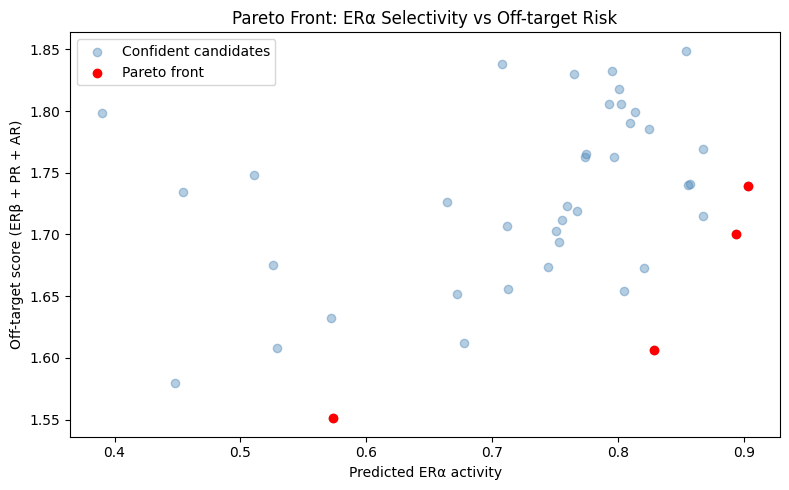

In [19]:
def is_pareto_efficient(costs):
    is_efficient = np.ones(len(costs), dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
            is_efficient[i] = True
    return is_efficient

# exclude high-uncertainty candidates
confident = scored_df[~scored_df['high_unc']].copy()

costs = np.column_stack([
    -confident['ERa_mean'].values,
     confident['ERb_mean'].values + confident['PR_mean'].values + confident['AR_mean'].values
])
pareto_mask  = is_pareto_efficient(costs)
pareto_front = confident[pareto_mask].copy()

print(f"Confident candidates: {len(confident)}")
print(f"Pareto-optimal:       {len(pareto_front)}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    confident['ERa_mean'],
    confident['ERb_mean'] + confident['PR_mean'] + confident['AR_mean'],
    alpha=0.4, label='Confident candidates', color='steelblue'
)
ax.scatter(
    pareto_front['ERa_mean'],
    pareto_front['ERb_mean'] + pareto_front['PR_mean'] + pareto_front['AR_mean'],
    color='red', zorder=5, label='Pareto front'
)
ax.set_xlabel('Predicted ERα activity')
ax.set_ylabel('Off-target score (ERβ + PR + AR)')
ax.set_title('Pareto Front: ERα Selectivity vs Off-target Risk')
ax.legend()
plt.tight_layout()
plt.savefig('pareto_front.png', dpi=150)
plt.show()


## Computational Validation
Future work: AutoDock Vina

In [20]:
from rdkit.Chem import Descriptors
from rdkit.Chem.rdMolDescriptors import CalcTPSA
from rdkit.Chem import RDConfig
import sys, os

sa_path = os.path.join(RDConfig.RDContribDir, 'SA_Score')
if sa_path not in sys.path:
    sys.path.append(sa_path)
import sascorer

def admet_profile(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = Descriptors.NumHDonors(mol)
    hba  = Descriptors.NumHAcceptors(mol)
    tpsa = CalcTPSA(mol)
    sa   = sascorer.calculateScore(mol)
    return {
        'MW':       round(mw, 2),
        'LogP':     round(logp, 2),
        'HBD':      hbd,
        'HBA':      hba,
        'TPSA':     round(tpsa, 2),
        'SA_score': round(sa, 2),
        'Ro5_pass': mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10,
        'SA_pass':  sa <= 4.0,
    }

admet_rows = []
for _, row in pareto_front.iterrows():
    profile = admet_profile(row['smiles'])
    if profile:
        profile['smiles']   = row['smiles']
        profile['ERa_mean'] = row['ERa_mean']
        profile['ERa_std']  = row['ERa_std']
        profile['all_pass'] = profile['Ro5_pass'] and profile['SA_pass']
        admet_rows.append(profile)

admet_df  = pd.DataFrame(admet_rows)
shortlist = admet_df[admet_df['all_pass']].sort_values('ERa_mean', ascending=False)

print(f"Pareto candidates passing all ADMET filters: {len(shortlist)} / {len(admet_df)}")
print(shortlist[['smiles', 'ERa_mean', 'ERa_std', 'MW', 'LogP', 'SA_score']].to_string(index=False))

Pareto candidates passing all ADMET filters: 4 / 4
                            smiles  ERa_mean  ERa_std     MW  LogP  SA_score
Cc1cc(CC(F)c2ccc(O)cc2Cl)c(Cl)cc1O  0.903050 0.045944 315.17  4.97      3.10
CC(c1ccc(O)cc1)C(N)c1ccc(O)c(Cl)c1  0.893576 0.028786 277.75  3.55      2.94
       ONCc1cc(CCc2ccc(O)cc2)ccc1O  0.828824 0.027502 259.31  2.36      2.16
   Nc1cc(O)cc(N)c1CCc1ccc(O)c(O)c1  0.573430 0.091465 260.29  1.75      2.54
